In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Messy_Employee_dataset.csv')
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   object 
 1   First_Name         1020 non-null   object 
 2   Last_Name          1020 non-null   object 
 3   Age                809 non-null    float64
 4   Department_Region  1020 non-null   object 
 5   Status             1020 non-null   object 
 6   Join_Date          1020 non-null   object 
 7   Salary             996 non-null    float64
 8   Email              1020 non-null   object 
 9   Phone              1020 non-null   int64  
 10  Performance_Score  1020 non-null   object 
 11  Remote_Work        1020 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(8)
memory usage: 88.8+ KB


## It tell about the percent of missing value

In [4]:
df.isnull().sum() /len(df) * 100

Employee_ID           0.000000
First_Name            0.000000
Last_Name             0.000000
Age                  20.686275
Department_Region     0.000000
Status                0.000000
Join_Date             0.000000
Salary                2.352941
Email                 0.000000
Phone                 0.000000
Performance_Score     0.000000
Remote_Work           0.000000
dtype: float64

## summary statistics 

In [5]:
df.describe().round()

,Age,Salary,Phone
count,809.0,996.0,1.020000e+03
mean,32.0,85155.0,-4.942253e+09
std,6.0,19874.0,2.817326e+09
min,25.0,50047.0,-9.994973e+09
25%,25.0,68392.0,-7.341992e+09
50%,30.0,85548.0,-4.943997e+09
75%,40.0,100974.0,-2.520391e+09
max,40.0,119972.0,-3.896086e+06


In [6]:
df.shape

(1020, 12)

In [7]:
df['Performance_Score'].value_counts()

Performance_Score
Good         270
Average      267
Excellent    267
Poor         216
Name: count, dtype: int64

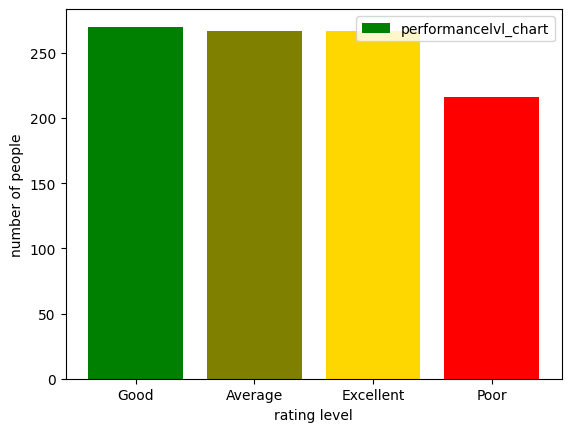

In [8]:
import matplotlib.pyplot as plt

rating = df['Performance_Score'].value_counts()
plt.bar(rating.index, rating.values, label='performancelvl_chart', color=['green','olive','gold','red'])
plt.xlabel('rating level')
plt.ylabel('number of people')
plt.legend()

## duplicated data

In [9]:
df.duplicated().value_counts()

False    1020
Name: count, dtype: int64

In [10]:
df['Employee_ID'].value_counts()

Employee_ID
EMP1000    1
EMP1685    1
EMP1672    1
EMP1673    1
EMP1674    1
          ..
EMP1344    1
EMP1345    1
EMP1346    1
EMP1347    1
EMP2019    1
Name: count, Length: 1020, dtype: int64

## here which ever column have less then 20 unique value, that will be displayed  

In [11]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(df[col].value_counts())
        print('-'*50)

First_Name
Frank      142
Grace      140
Eva        136
Bob        133
Charlie    125
Alice      117
David      116
Heidi      111
Name: count, dtype: int64
--------------------------------------------------
Last_Name
Brown       148
Garcia      136
Smith       136
Jones       131
Davis       120
Johnson     118
Miller      116
Williams    115
Name: count, dtype: int64
--------------------------------------------------
Age
40.0    210
25.0    206
30.0    205
35.0    188
Name: count, dtype: int64
--------------------------------------------------
Status
Pending     356
Active      352
Inactive    312
Name: count, dtype: int64
--------------------------------------------------
Performance_Score
Good         270
Average      267
Excellent    267
Poor         216
Name: count, dtype: int64
--------------------------------------------------
Remote_Work
True     513
False    507
Name: count, dtype: int64
--------------------------------------------------


## putting the mean value in place of null

In [80]:
df['Age'] = df['Age'].astype('int64') # int64 will give back int and null value as nan
df_mean = int(df['Age'].dropna().mean()) # from age column remove nan and put mean value there
df_mean

32

In [13]:
df.fillna({'Age': df_mean}, inplace = True)
df['Age'].unique()

<IntegerArray>
[25, 32, 40, 30, 35]
Length: 5, dtype: Int64

In [14]:
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,32,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,32,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [15]:
salary_mean = df['Salary'].mean()
df.fillna({'Salary': salary_mean}, inplace = True)

In [16]:
df.isnull().sum()   

Employee_ID          0
First_Name           0
Last_Name            0
Age                  0
Department_Region    0
Status               0
Join_Date            0
Salary               0
Email                0
Phone                0
Performance_Score    0
Remote_Work          0
dtype: int64

## remove the - sign from front of the number

In [17]:
df['Phone']=abs(df['Phone'])

In [24]:
df['Last_Name'].unique()

array(['Davis', 'Brown', 'Jones', 'Williams', 'Garcia', 'Johnson',
       'Miller', 'Smith'], dtype=object)

In [29]:
df['Department_Region'] = df['Department_Region'].str.lower().str.strip()

In [37]:
df[df.duplicated].shape

(0, 12)

In [44]:
count = df['Email'].value_counts()
if (count.values >1).any():
    print('yes')
else:
    print('no')

yes


In [39]:
df[df['Employee_ID']=='EMP1001']

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
1,EMP1001,Bob,Brown,32,finance-texas,Active,7/10/2020,65304.66,bob.brown@example.com,1898471390,Excellent,True


In [42]:
df['Employee_ID'].nunique()

1020

## this way I check the data type of each column

In [53]:
df.dtypes

Employee_ID                  object
First_Name                   object
Last_Name                    object
Age                           Int64
Department_Region            object
Status                       object
Join_Date            datetime64[ns]
Salary                      float64
Email                        object
Phone                         int64
Performance_Score            object
Remote_Work                    bool
dtype: object

In [52]:
df['Join_Date'] = pd.to_datetime(df['Join_Date'])

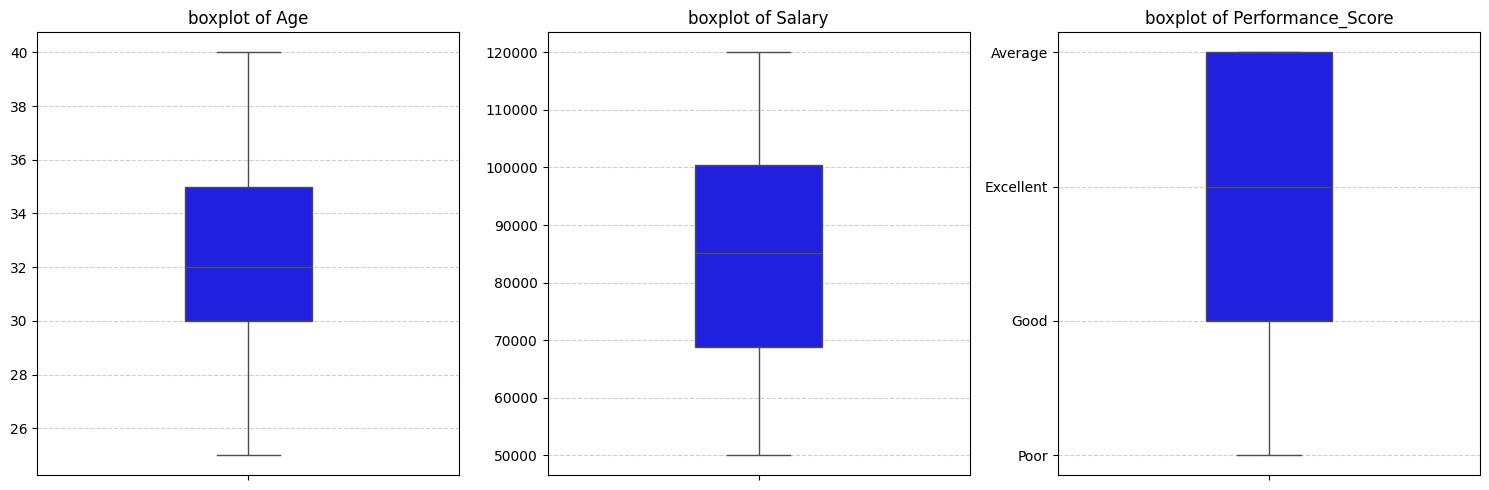

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt


cols = ['Age', 'Salary', 'Performance_Score']

fig, ax = plt.subplots(1,3, figsize=(15,5))

for i, col in enumerate(cols):
    sns.boxplot(y= df_clean[col], ax= ax[i] , color= 'blue', width= 0.3)
    ax[i].set_title(f'boxplot of {col}', fontsize= 12)
    ax[i].set_ylabel('')
    ax[i].grid(axis= 'y', linestyle='--', alpha= 0.6)

plt.tight_layout()
plt.show()

In [95]:
from scipy import stats
import numpy as np

z_score = np.abs(stats.zscore(df[['Age','Salary']]))
df_clean = df[~(z_score > 3).any(axis=1)]